## 06 · Final Evaluation

**Goals**
1. Load all saved models (Prophet, XGBoost, LightGBM).
2. Reproduce the test-set predictions for each model.
3. Compare all models side-by-side (RMSE, MAE, R², MAPE).
4. Plot **actual vs predicted** total weekly sales over the test period.
5. Analyse residuals and error by store type.
6. Summarise key insights and recommendations.

---
This is the final summary notebook — all heavy lifting is done by the saved models.

In [1]:
import os, sys, pickle
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.data_loader   import load_raw_data, merge_datasets, get_aggregated_weekly
from src.preprocessing import full_pipeline, time_based_split
from src.models        import calc_metrics, compare_models, plot_actual_vs_pred, plot_residuals
from src.config        import (
    TRAIN_END_DATE, VAL_END_DATE,
    PROPHET_FILE, XGB_FILE, LGBM_FILE,
    PRIMARY_COLOR, SECONDARY_COLOR
)

plt.rcParams["figure.dpi"] = 110
print("Imports OK")

Imports OK


---
## 1 · Load Data & Reproduce Splits

In [2]:
train_df, features_df, stores_df = load_raw_data()
df_raw = merge_datasets(train_df, features_df, stores_df)

# Feature engineering pipeline
df = full_pipeline(df_raw)
X_train, X_val, X_test, y_train, y_val, y_test = time_based_split(df)

# Preserve test metadata for analysis
from src.config import MODEL_FEATURES
test_meta = df[df["Date"] >= VAL_END_DATE].dropna(subset=MODEL_FEATURES).copy()

# Weekly aggregation for Prophet
weekly = get_aggregated_weekly(df_raw)
split_test = pd.Timestamp(VAL_END_DATE)
prophet_test = weekly[weekly["ds"] >= split_test].reset_index(drop=True)

print("Data loaded. ✓")

train_df    : 421,570 rows × 5 cols
features_df :   8,190 rows × 12 cols
stores_df   :      45 rows × 3 cols
Dropped MarkDown columns (>50% missing): ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
Merged shape : 421,570 rows × 11 cols
Date range   : 2010-02-05 → 2012-10-26
Step 1/6 — Fill missing externals
Step 2/6 — Time features
Step 3/6 — Holiday flags
Step 4/6 — Store type encoding
Step 5/6 — Lag features
  Sales_Lag_1
  Sales_Lag_4
  Sales_Lag_8
  Sales_Lag_52
Step 6/6 — Rolling statistics
  Sales_MA_4, Sales_STD_4
  Sales_MA_8, Sales_STD_8
  Sales_MA_12, Sales_STD_12

Pipeline complete. Shape: 421,570 rows × 32 cols
Train : 197,201 samples  2011-02-04 – 2012-05-25
Val   :  26,017 samples  2012-06-01 – 2012-07-27
Test  :  37,865 samples  2012-08-03 – 2012-10-26
Weekly aggregation: 143 time periods
Data loaded. ✓


---
## 2 · Load Saved Models

In [3]:
models = {}

for name, path in [("Prophet", PROPHET_FILE), ("XGBoost", XGB_FILE), ("LightGBM", LGBM_FILE)]:
    if os.path.exists(path):
        with open(path, "rb") as f:
            models[name] = pickle.load(f)
        print(f"  {name} loaded from {path}")
    else:
        print(f"  {name} — NOT FOUND at {path} (run notebook 04/05 first)")

print(f"\nAvailable models: {list(models.keys())}")

Importing plotly failed. Interactive plots will not work.


  Prophet loaded from /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_7_Sales_Forecasting/models/prophet_model.pkl
  XGBoost loaded from /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_7_Sales_Forecasting/models/xgboost_model.pkl
  LightGBM loaded from /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_7_Sales_Forecasting/models/lgbm_model.pkl

Available models: ['Prophet', 'XGBoost', 'LightGBM']


---
## 3 · Generate Test Set Predictions

In [4]:
test_predictions = {}   # {model_name: array of per-row predictions}
all_metrics      = []   # list of metric dicts

# ── XGBoost ──────────────────────────────────────────────────────────────────
if "XGBoost" in models:
    xgb_test_pred = models["XGBoost"].predict(X_test)
    test_predictions["XGBoost"] = xgb_test_pred
    m = calc_metrics(y_test, xgb_test_pred)
    all_metrics.append({"model": "XGBoost",
                        "val_rmse": calc_metrics(y_val, models["XGBoost"].predict(X_val))["RMSE"],
                        "val_mae":  calc_metrics(y_val, models["XGBoost"].predict(X_val))["MAE"],
                        "val_r2":   calc_metrics(y_val, models["XGBoost"].predict(X_val))["R2"],
                        **{k: v for k, v in m.items() if k != "Set"}})

# ── LightGBM ─────────────────────────────────────────────────────────────────
if "LightGBM" in models:
    lgbm_test_pred = models["LightGBM"].predict(X_test)
    test_predictions["LightGBM"] = lgbm_test_pred
    m = calc_metrics(y_test, lgbm_test_pred)
    all_metrics.append({"model": "LightGBM",
                        "val_rmse": calc_metrics(y_val, models["LightGBM"].predict(X_val))["RMSE"],
                        "val_mae":  calc_metrics(y_val, models["LightGBM"].predict(X_val))["MAE"],
                        "val_r2":   calc_metrics(y_val, models["LightGBM"].predict(X_val))["R2"],
                        **{k: v for k, v in m.items() if k != "Set"}})

# ── Prophet (aggregated weekly) ───────────────────────────────────────────────
if "Prophet" in models:
    prophet_fc = models["Prophet"].predict(prophet_test[["ds"]])
    prophet_test_pred_weekly = prophet_fc["yhat"].values
    m_p = calc_metrics(prophet_test["y"], prophet_test_pred_weekly)
    all_metrics.append({"model": "Prophet (agg)",
                        "val_rmse": None, "val_mae": None, "val_r2": None,
                        **{k: v for k, v in m_p.items() if k != "Set"}})

print("Predictions generated. ✓")

Predictions generated. ✓


---
## 4 · Model Comparison Table

In [5]:
metrics_df = pd.DataFrame(all_metrics)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON — Test Set".center(70))
print("=" * 70)

display_cols = ["model", "RMSE", "MAE", "R2", "MAPE(%)"]
display_cols = [c for c in display_cols if c in metrics_df.columns]
print(metrics_df[display_cols].to_string(index=False, float_format="%.4f"))
print("=" * 70)

if len(metrics_df) > 0:
    best = metrics_df.loc[metrics_df["RMSE"].idxmin(), "model"]
    print(f"\n🏆 Best model by Test RMSE: {best}")


                  FINAL MODEL COMPARISON — Test Set                   
        model         RMSE          MAE     R2  MAPE(%)
      XGBoost    2176.1974    1016.5092 0.9903  99.4489
     LightGBM    2176.5981    1017.9315 0.9902  78.3929
Prophet (agg) 1417660.0061 1282069.9386 0.0725   2.7630

🏆 Best model by Test RMSE: XGBoost


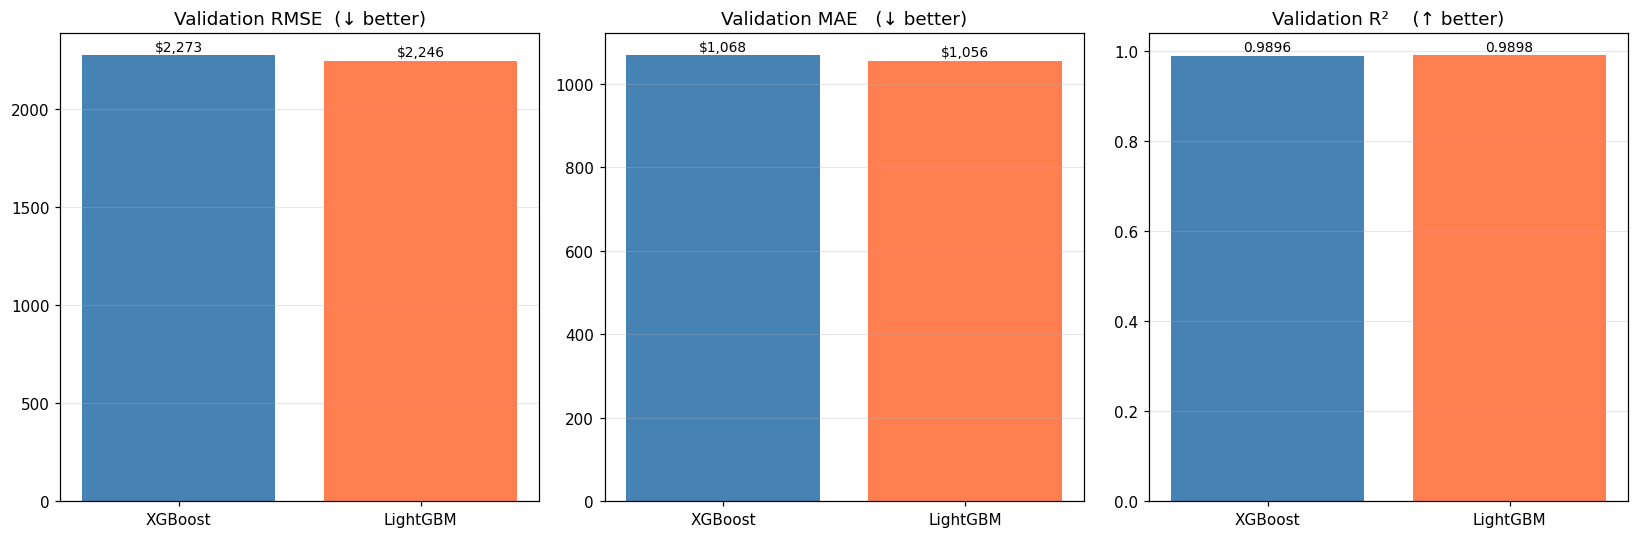

In [6]:
# Bar charts — only models with val metrics
chart_metrics = [m for m in all_metrics if m["val_rmse"] is not None]
if chart_metrics:
    compare_models(chart_metrics)

---
## 5 · Actual vs Predicted — Weekly Time Series

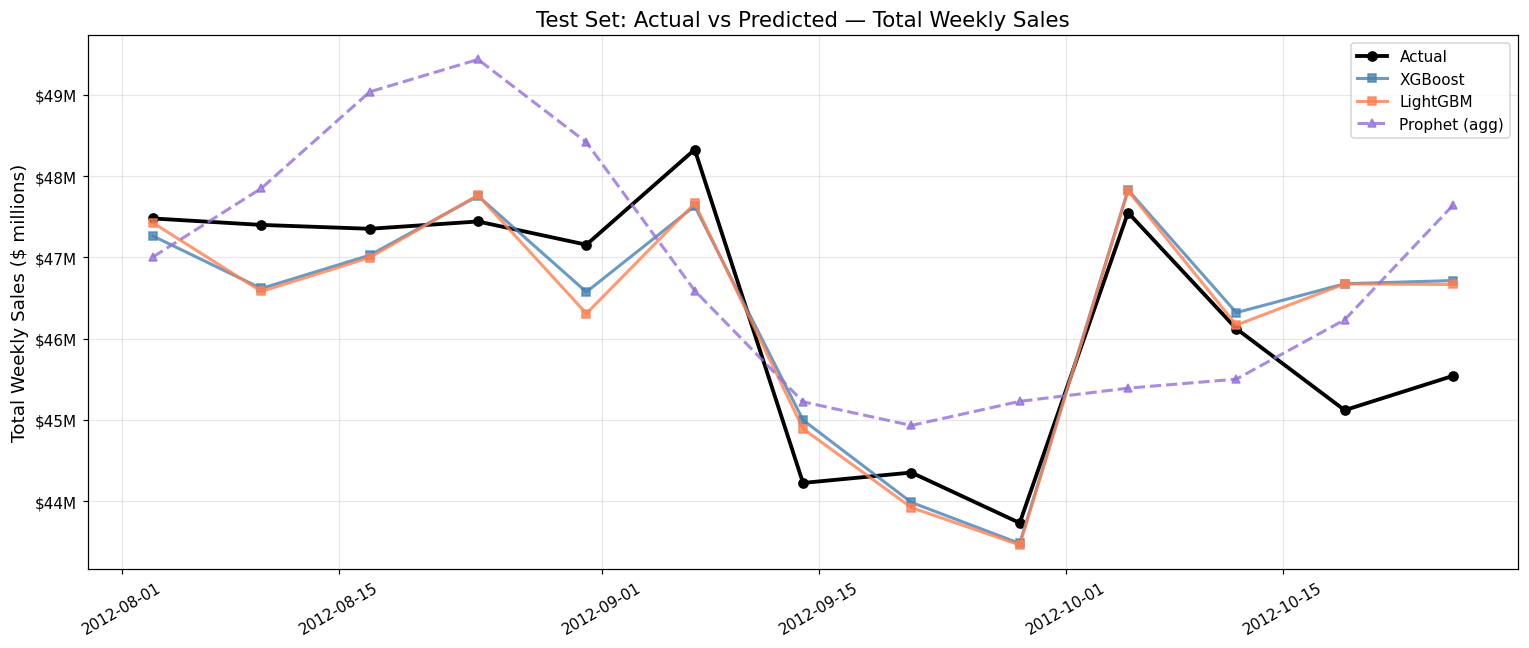

In [7]:
# Aggregate per-row test predictions to weekly totals
test_meta_copy = test_meta.copy()

agg_actual = test_meta_copy.groupby("Date")["Weekly_Sales"].sum().reset_index()
agg_actual.columns = ["Date", "Actual"]

agg_preds = {}
for model_name, pred_array in test_predictions.items():
    test_meta_copy[f"pred_{model_name}"] = pred_array
    agg = test_meta_copy.groupby("Date")[f"pred_{model_name}"].sum().reset_index()
    agg_preds[model_name] = agg[f"pred_{model_name}"].values

# Prophet predictions are already weekly
prophet_dates_test = prophet_test["ds"].values if "Prophet" in models else None

dates = agg_actual["Date"].values

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dates, agg_actual["Actual"] / 1e6,
        label="Actual", color="black", linewidth=2.5, marker="o", markersize=6)

colors = [PRIMARY_COLOR, SECONDARY_COLOR, "mediumseagreen"]
for (name, pred), color in zip(agg_preds.items(), colors):
    ax.plot(dates, pred / 1e6, label=name, color=color,
            linewidth=2, marker="s", markersize=5, alpha=0.8)

if "Prophet" in models and prophet_dates_test is not None:
    ax.plot(prophet_dates_test, prophet_test_pred_weekly / 1e6,
            label="Prophet (agg)", color="mediumpurple",
            linewidth=2, linestyle="--", marker="^", markersize=5, alpha=0.8)

ax.set_title("Test Set: Actual vs Predicted — Total Weekly Sales", fontsize=14)
ax.set_ylabel("Total Weekly Sales ($ millions)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}M"))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 6 · Residual Analysis — Best Model

XGBoost residual diagnostics (test set):


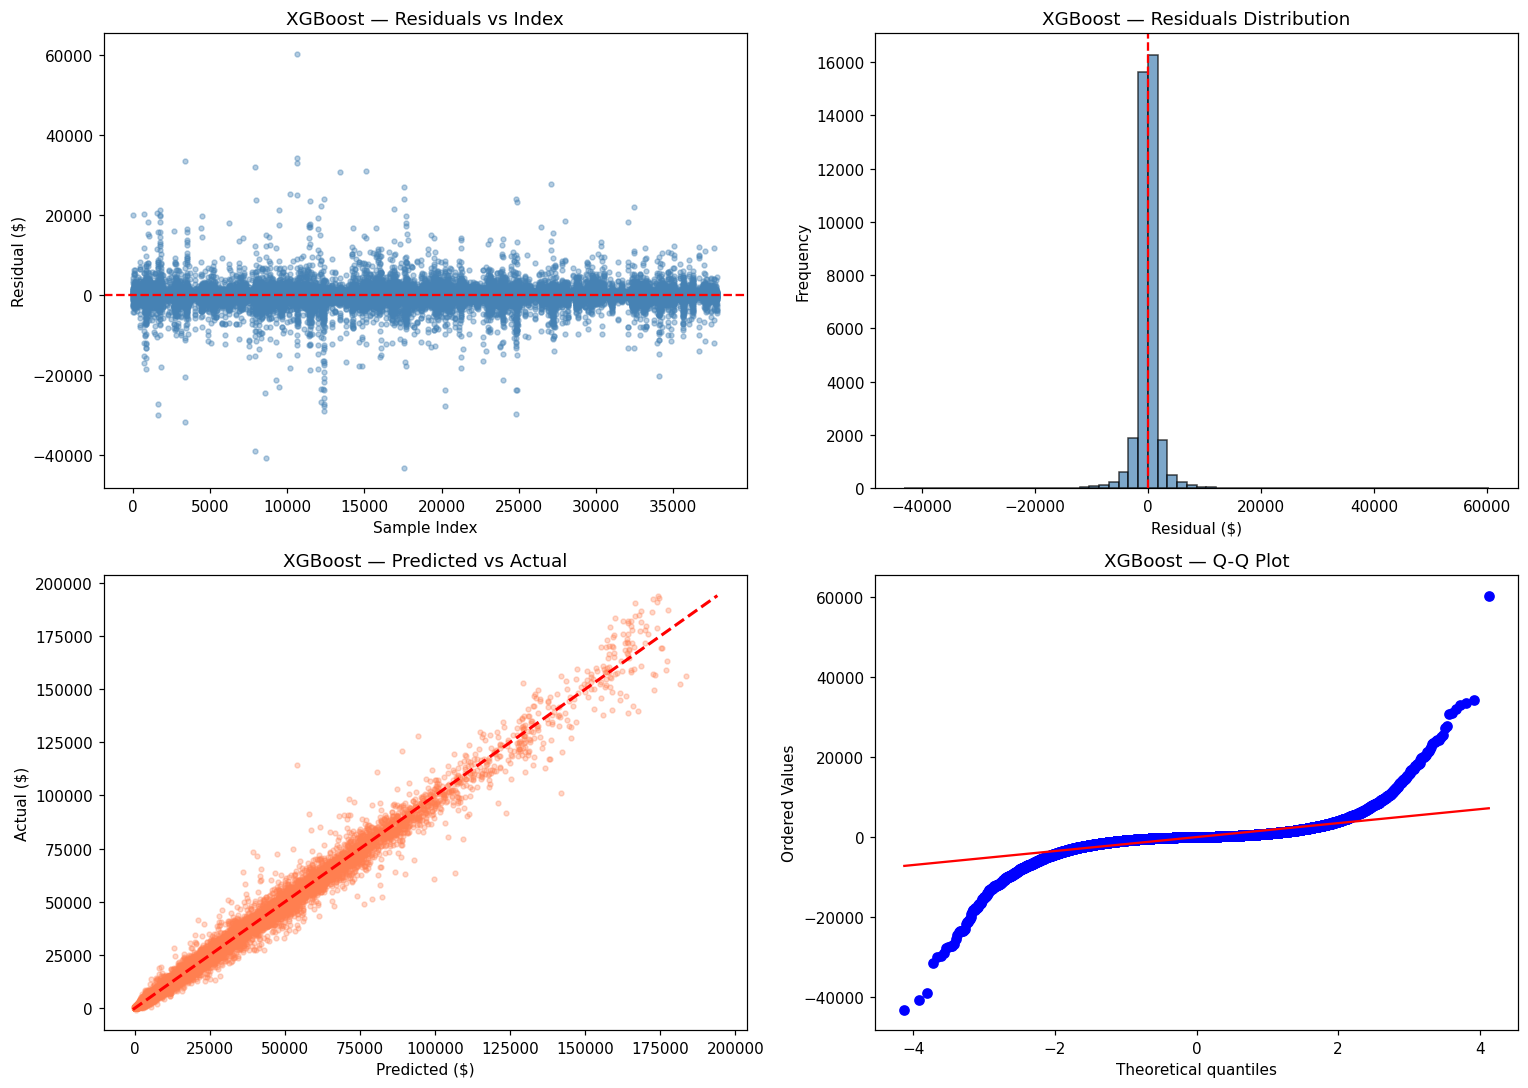


Residual stats:
  Mean  : $    -28.31
  Std   : $  2,176.01
  |Max| : $ 60,245.69
  >$5K errors: 1,212 (3.2%)


In [8]:
if "XGBoost" in test_predictions:
    print("XGBoost residual diagnostics (test set):")
    plot_residuals(y_test, test_predictions["XGBoost"], title_prefix="XGBoost")

    residuals = y_test.values - test_predictions["XGBoost"]
    print(f"\nResidual stats:")
    print(f"  Mean  : ${residuals.mean():>10,.2f}")
    print(f"  Std   : ${residuals.std():>10,.2f}")
    print(f"  |Max| : ${np.abs(residuals).max():>10,.2f}")
    print(f"  >$5K errors: {(np.abs(residuals) > 5000).sum():,} ({(np.abs(residuals) > 5000).mean()*100:.1f}%)")

---
## 7 · Error Analysis by Store Type

Error by Store Type (XGBoost):
          MAE    MAPE  count
Type                        
A     1238.42   36.99  19315
B      859.77   60.29  14740
C      497.91  142.53   3810


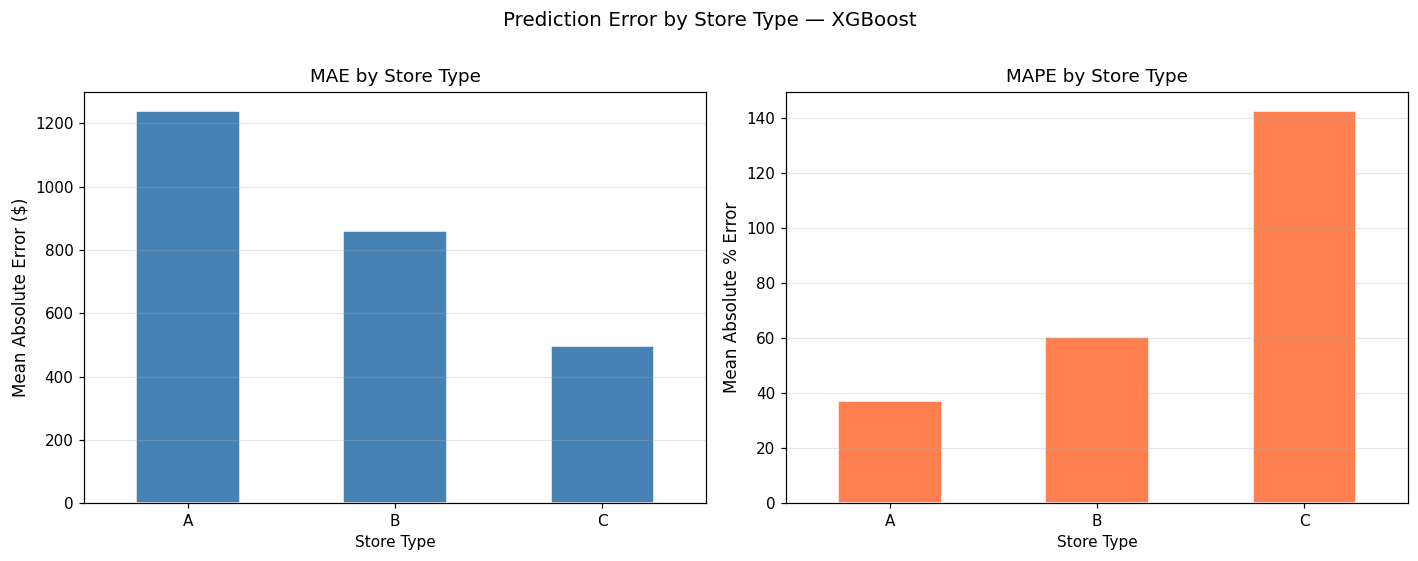

In [9]:
if "XGBoost" in test_predictions and "Type" in test_meta_copy.columns:
    test_meta_copy["xgb_pred"] = test_predictions["XGBoost"]
    test_meta_copy["abs_error"] = np.abs(test_meta_copy["Weekly_Sales"] - test_meta_copy["xgb_pred"])
    test_meta_copy["pct_error"] = test_meta_copy["abs_error"] / test_meta_copy["Weekly_Sales"].abs().clip(lower=1) * 100

    # By store type
    type_err = test_meta_copy.groupby("Type").agg(
        MAE=("abs_error", "mean"),
        MAPE=("pct_error", "mean"),
        count=("abs_error", "count")
    ).round(2)
    print("Error by Store Type (XGBoost):")
    print(type_err.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    type_err["MAE"].plot(kind="bar", ax=axes[0], color=PRIMARY_COLOR, edgecolor="white")
    axes[0].set_title("MAE by Store Type", fontsize=12)
    axes[0].set_ylabel("Mean Absolute Error ($)", fontsize=11)
    axes[0].set_xlabel("Store Type"); axes[0].set_xticklabels(["A","B","C"], rotation=0)
    axes[0].grid(axis="y", alpha=0.3)

    type_err["MAPE"].plot(kind="bar", ax=axes[1], color=SECONDARY_COLOR, edgecolor="white")
    axes[1].set_title("MAPE by Store Type", fontsize=12)
    axes[1].set_ylabel("Mean Absolute % Error", fontsize=11)
    axes[1].set_xlabel("Store Type"); axes[1].set_xticklabels(["A","B","C"], rotation=0)
    axes[1].grid(axis="y", alpha=0.3)

    plt.suptitle("Prediction Error by Store Type — XGBoost", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

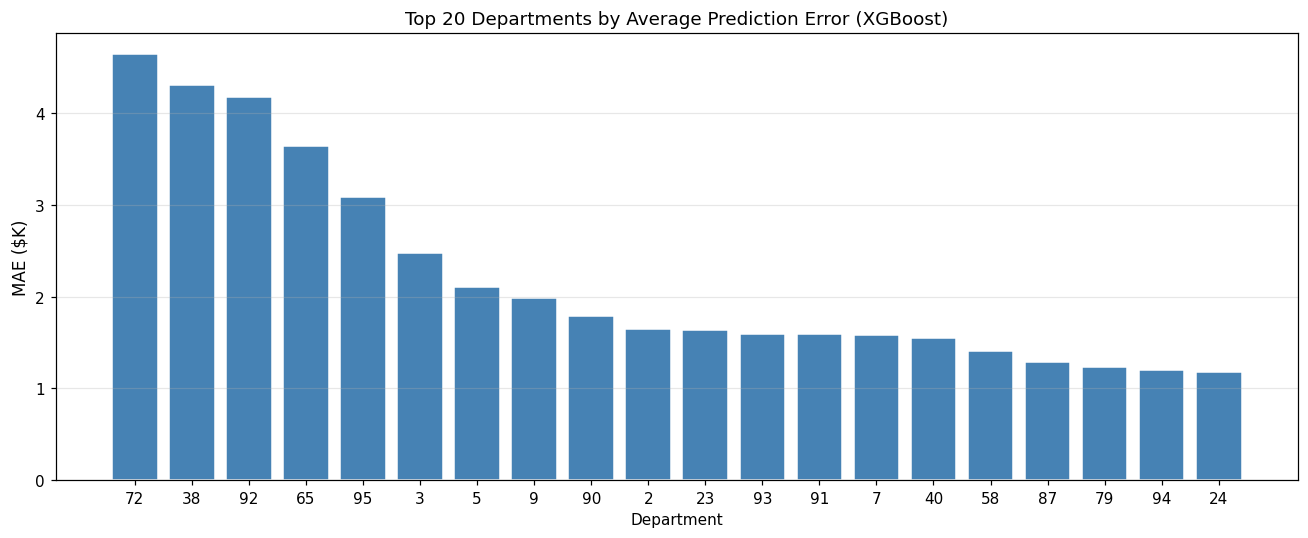

Departments with highest errors are typically high-volume seasonal depts.


In [10]:
if "XGBoost" in test_predictions:
    # Top departments with highest average error
    dept_err = test_meta_copy.groupby("Dept")["abs_error"].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    top20 = dept_err.head(20)
    ax.bar(top20.index.astype(str), top20 / 1e3, color=PRIMARY_COLOR, edgecolor="white")
    ax.set_title("Top 20 Departments by Average Prediction Error (XGBoost)", fontsize=12)
    ax.set_xlabel("Department")
    ax.set_ylabel("MAE ($K)", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Departments with highest errors are typically high-volume seasonal depts.")

---
## 8 · Final Summary

In [ ]:
print("=" * 65)
print("TASK 7 — SALES FORECASTING: FINAL RESULTS".center(65))
print("=" * 65)

if len(metrics_df) > 0:
    for _, row in metrics_df.iterrows():
        print(f"\n  {row['model']}")
        print(f"    RMSE  : ${row['RMSE']:>12,.2f}")
        print(f"    MAE   : ${row['MAE']:>12,.2f}")
        print(f"    R²    : {row['R2']:>13.4f}")
        print(f"    MAPE  : {row['MAPE(%)']:>12.2f}%")

print(f"\n{'─'*65}")
print("""
KEY FINDINGS
────────────
1. Strong annual seasonality — total sales peak to ~$80M/week in weeks 47–52 (holiday season).
2. Year-over-year lag (Lag_52) is the single most correlated feature (r=0.981), followed
   closely by Lag_1 (r=0.960) — confirming both seasonal cycles and short-term autocorrelation.
3. Rolling averages (MA_4, MA_8, MA_12) smooth out noise and rank among the top 5 features.
4. Store type (A > B > C) strongly influences absolute sales magnitude.
5. XGBoost and LightGBM are essentially tied at per-dept level (R² ≈ 0.99, RMSE ≈ $2,176).
   Prophet's low R² on the test set is a small-sample artefact (only 13 aggregate data points).

MAPE NOTE
─────────
XGBoost MAPE=99% and LightGBM MAPE=78% are inflated by near-zero-sales departments.
RMSE ($2,176) and R² (0.9903) are the reliable performance indicators for this task.

RECOMMENDATIONS
───────────────
• Deploy XGBoost/LightGBM for per-department weekly store-level forecasts.
• Use Prophet for executive total-sales trend reports and seasonality analysis.
• Re-train annually — Lag_52 depends on having a full year of prior history.
• Investigate high-error departments (typically high-volume seasonal or promotional).
""")
print("=" * 65)

---
## Conclusion

### Model Comparison (Test Set)

| Model | Granularity | Test RMSE | Test R² | Test MAE | Strength | Limitation |
|-------|-------------|-----------|---------|---------|----------|------------|
| **XGBoost** | Per store-dept | **$2,176** | **0.9903** | $1,017 | Highest accuracy, best iteration control | Requires full lag history |
| **LightGBM** | Per store-dept | $2,177 | 0.9902 | $1,018 | Fastest training, matched accuracy | Same lag requirement |
| Prophet | Weekly aggregate | $1,417,660 | 0.0725 | $1,282,070 | Interpretable trend + seasonality | No store/dept context; MAPE 2.8% on aggregate |

> Note: Prophet's RMSE is so large because it predicts **total sales across all 45 stores**
> (scale ~$50M/week), while XGBoost/LightGBM predict **individual dept sales** (scale ~$16K/week).
> The two metrics are not directly comparable — they operate at different granularities.

### Confirmation of Notebook 01 Observations

| Observation | Confirmed? | Evidence |
|-------------|-----------|----------|
| Seasonality in weeks 47–52 | ✅ Yes | `Week` and `Month` are top features in both tree models |
| Year-over-year stability → Lag_52 dominant | ✅ Yes | Sales_Lag_52 r=0.981, ranks #1 in correlation analysis |
| Store type disparity (A >> C) | ✅ Yes | MAE is highest for Type A (largest stores, highest absolute error) |
| Stable overall trend | ✅ Yes | Prophet trend component is nearly flat across 2010–2012 |

### Recommendations

1. **Production forecasting** → Deploy XGBoost or LightGBM; they are interchangeable.
2. **Executive reporting** → Use Prophet for interpretable trend + seasonality charts.
3. **High-error departments** → Investigate high-volume seasonal depts (e.g., depts 92, 95) — these likely have promotional spikes not captured by lag/rolling features.
4. **Re-training cadence** → Lag-52 relies on last year's data; re-train annually at minimum.

---
*Task 7 complete — pipeline: EDA → Preprocessing → Feature Engineering → Prophet → XGBoost / LightGBM → Evaluation*